In [1]:
print ("hi")

hi


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import cvxpy as cp

In [ ]:
class LogisticRegressionClass:

    def __init__(self, n, d, random_seed = 42, eta = 0.1):
        self.d = d
        self.n = n
        self.rng = np.random.default_rng(random_seed)
        self.eta = eta
    def ell(self, t):
        return np.logaddexp(0,-t)
    
    def zero_one_loss(self, w, X_data, y_data):
        n = len(X_data)
        predictions = np.sign(X_data @ w)
        return (1/n) * np.sum(predictions != y_data)

    def logistic_loss(self, w, X_data, y_data):
        n = len(X_data)
        return (1/n) * np.sum(self.ell( y_data * (X_data @ w)))

    def calibration_error(self):
        pass
    
    
    def oracular_ell_hat_w_star_zero_to_k(self, X_data, y_data,
                                          w_star,  Sigma=None, k=None,
                                          ):
        
        # Note: This function is not implemented for the general case! 
        # Right now, it just returns \hat{L}(w*) since w* = w*_{0:k} in our specific case
        return self.logistic_loss(w_star, X_data, y_data)
    
    def generate_data(self, d, n, w_star, Sigma = None, lambda_diag = None, use_lambda_diag=True):

        # LLM GENERATED PART ---------------------- 
        # generate X: sample N(0, I) then scale by sqrt(lambda)
        if use_lambda_diag:
            Z = self.rng.standard_normal((n, d))
            X_data = Z * np.sqrt(lambda_diag)  # broadcasts across rows
        else:
            X_data = self.rng.multivariate_normal(np.zeros(d), Sigma, size = n)
        # ------------------------------------------


        # generate y
        probs = 1.0/(1.0 + np.exp(- X_data @ w_star))
        random_draws = self.rng.uniform(low=0, high=1, size = n)
        y_data = - 1 + 2 * (random_draws <= probs).astype(float)

        return X_data, y_data

    def sigmoid(self, x):
        return np.where(x >= 0, 1/(1+np.exp(-x)), np.exp(x)/(1+np.exp(x)))

    def grad(self, w, X_data, y_data):
        n = len(X_data)
        return - (1/n) * X_data.T @ ((1-self.sigmoid(y_data * (X_data @ w)))*y_data)

    def record_the_error(n, mode = "all"):
        if mode == "all":
            return True
        if mode == "log": 
            return n > 0 and 10 ** round(math.log10(n)) == n # note: this line is generated by LLM and not carefully checked
        return False

    def run_GD_for_t_steps(self, X_data, y_data, X_valid=None, 
                           y_valid=None, X_test=None, y_test=None, 
                           w_0 = None, eta = None, t_steps = 10
                           , store_log_loss_traj_for_training = True
                           , store_log_loss_traj_for_validation = False
                           , store_log_loss_traj_for_test = False
                           , store_zero_one_loss_traj_for_training = True
                           , store_zero_one_loss_traj_for_validation = False
                           , store_zero_one_loss_traj_for_test = False
                           , store_w_trajectory = True):
        
        if w_0 is None:
            w_0 = np.zeros(self.d)#.reshape(-1,1)
        if eta is None:
            eta = self.eta

        logistic_loss_training_trajectory = []
        logistic_loss_validation_trajectory = []
        logistic_loss_test_trajectory = []

        zero_one_loss_training_trajectory = []
        zero_one_loss_validation_trajectory = []
        zero_one_loss_test_trajectory = []
        
        w_trajectory = []

        w_current = w_0

        # store w_0
        if store_w_trajectory:
            w_trajectory.append(w_current)

        for t in range(t_steps):
            # measure the error for w_prev

            # log loss ---------------------------------------
            if store_log_loss_traj_for_training:
                logistic_loss_training_trajectory.append(
                self.logistic_loss(
                    w_current, X_data, y_data
                    )
                )
            if store_log_loss_traj_for_validation:
                logistic_loss_validation_trajectory.append(
                self.logistic_loss(
                    w_current, X_valid, y_valid
                    )
                )
            if store_log_loss_traj_for_test:
                logistic_loss_test_trajectory.append(
                self.logistic_loss(
                    w_current, X_test, y_test
                    )
                )
            # zero-one loss --------------------------------------
            if store_zero_one_loss_traj_for_training:
                zero_one_loss_training_trajectory.append(
                    self.zero_one_loss(w_current, X_data, y_data)
                    )
            if store_zero_one_loss_traj_for_validation:
                zero_one_loss_validation_trajectory.append(
                    self.zero_one_loss(w_current, X_valid, y_valid)
                )
            if store_zero_one_loss_traj_for_test:
                zero_one_loss_test_trajectory.append(
                    self.zero_one_loss(w_current, X_test, y_test)
                )


            # gradient step
            w_new = w_current - eta * self.grad(w_current, X_data, y_data)
            w_current = w_new
            
            # store the w_t
            if store_w_trajectory:
                w_trajectory.append(w_current)

        return { 
            "log_loss_train": logistic_loss_training_trajectory,
            "log_loss_valid": logistic_loss_validation_trajectory,
            "log_loss_test": logistic_loss_test_trajectory,
            "zero_one_train": zero_one_loss_training_trajectory,
            "zero_one_valid": zero_one_loss_validation_trajectory,
            "zero_one_test": zero_one_loss_test_trajectory,
            "w_trajectory": w_trajectory,
            "w_last_iterate": w_current
        }
    
    
    def plot_loss_over_time(self, logistic_loss_training_trajectory=None, zero_one_loss_training_trajectory=None,
         logistic_loss_validation_trajectory=None, zero_one_loss_validation_trajectory=None,
         logistic_loss_test_trajectory=None, zero_one_loss_test_trajectory=None, eta=None,
         bayes_logistic_risk=None, bayes_zero_one_risk=None,
         oracle_stop_opt_length=None,
         show_oracular_early_stopping=False, L_hat_of_w_start_zero_to_k=None,
         show_validation_arg_min=False
         ):

        if eta is None:
            eta = self.eta

        def make_opt_length(traj):
            return eta * np.arange(1, len(traj))

        # find oracle stopping point: first t where L_hat(w_t) <= L_hat(w*_{0:k})
        oracle_stop_opt_length = None
        if show_oracular_early_stopping and L_hat_of_w_start_zero_to_k is not None and logistic_loss_training_trajectory is not None:
            for t, loss in enumerate(logistic_loss_training_trajectory):
                if loss <= L_hat_of_w_start_zero_to_k:
                    oracle_stop_opt_length = eta * t
                    break

        # compute validation argmin stopping point from validation log loss trajectory
        valid_stop_opt_length = None
        if show_validation_arg_min and logistic_loss_validation_trajectory is not None and len(logistic_loss_validation_trajectory) > 1:
            argmin_idx = np.argmin(logistic_loss_validation_trajectory[1:])
            valid_stop_opt_length = eta * (argmin_idx + 1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        if logistic_loss_training_trajectory is not None:
            opt_length = make_opt_length(logistic_loss_training_trajectory)
            axes[0].plot(opt_length, logistic_loss_training_trajectory[1:], label="training", color="tab:blue")
        if logistic_loss_validation_trajectory is not None:
            opt_length = make_opt_length(logistic_loss_validation_trajectory)
            axes[0].plot(opt_length, logistic_loss_validation_trajectory[1:], label="validation", color="tab:orange")
        if logistic_loss_test_trajectory is not None:
            opt_length = make_opt_length(logistic_loss_test_trajectory)
            axes[0].plot(opt_length, logistic_loss_test_trajectory[1:], label="test", color="tab:red")
        if bayes_logistic_risk is not None:
            axes[0].axhline(bayes_logistic_risk, linestyle=":", color="gray", label="bayes risk")
        if oracle_stop_opt_length is not None:
            axes[0].axvline(oracle_stop_opt_length, linestyle="--", color="green", label="oracle early stop")
        if valid_stop_opt_length is not None:
            axes[0].axvline(valid_stop_opt_length, linestyle="--", color="purple", label="valid early stop")
        axes[0].set_xscale("log")
        axes[0].set_yscale("log", base=2)
        axes[0].set_xlabel("opt length")
        axes[0].set_ylabel("logistic risk")
        axes[0].legend()

        if zero_one_loss_training_trajectory is not None:
            opt_length = make_opt_length(zero_one_loss_training_trajectory)
            axes[1].plot(opt_length, zero_one_loss_training_trajectory[1:], label="training", color="tab:blue")
        if zero_one_loss_validation_trajectory is not None:
            opt_length = make_opt_length(zero_one_loss_validation_trajectory)
            axes[1].plot(opt_length, zero_one_loss_validation_trajectory[1:], label="validation", color="tab:orange")
        if zero_one_loss_test_trajectory is not None:
            opt_length = make_opt_length(zero_one_loss_test_trajectory)
            axes[1].plot(opt_length, zero_one_loss_test_trajectory[1:], label="test", color="tab:red")
        if bayes_zero_one_risk is not None:
            axes[1].axhline(bayes_zero_one_risk, linestyle=":", color="gray", label="bayes risk")
        if oracle_stop_opt_length is not None:
            axes[1].axvline(oracle_stop_opt_length, linestyle="--", color="green", label="oracle early stop")
        if valid_stop_opt_length is not None:
            axes[1].axvline(valid_stop_opt_length, linestyle="--", color="purple", label="valid early stop")
        axes[1].set_xscale("log")
        axes[1].set_xlabel("opt length")
        axes[1].set_ylabel("zero-one error")
        axes[1].legend()

        plt.tight_layout()
        plt.show()
        
    def find_w_tilde(self, X_data, y_data, normalize=False): # Note: LLM generated
        n, d = X_data.shape
        Xy = X_data * y_data[:, None]                      # rows: y_i * x_i

        w = cp.Variable(d)
        objective = cp.Minimize(0.5 * cp.sum_squares(w))
        constraints = [Xy @ w >= 1]                        # y_i (x_i . w) >= 1
        prob = cp.Problem(objective, constraints)
        prob.solve()

        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"SVM QP not solved (status={prob.status}); "
                            "is the data linearly separable?")
        w_val = np.asarray(w.value).ravel()
        return w_val / np.linalg.norm(w_val) if normalize else w_val
    
    

    def region_experiment_v1(self,number_of_trajectories):

        # trajectories = []

        # generate data for k = number of trajectories
        # for i in range (0, k)
        # run GD for each one
        # # 1) Store the trajectory
        # # 2) find w_tilde
        # trajectories[i] = trajectory
        # w_tilde[i] = w_tilde
        # then plot all trajectories in space of 
        # w_1 = w^*
        # w_2 = sum of all w_tilde[i]
        # see how it looks
        # I'm testinggg11
        # 1
        pass

    def plot_trajectory_over(self, w_1, w_2, trajectory_dict_perhaps):
        pass

    def LLM_generated_region_experiment_v1(self, number_of_trajectories, w_star,
                                            d=None, n=None, t_steps=1000, eta=None,
                                            Sigma=None, lambda_diag=None, use_lambda_diag=True,
                                            normalize_w_tilde=False, plot=True):
        
        # LLM GENERATED PART ----------------------
        # Implements the plan sketched in region_experiment_v1:
        #   for each of `number_of_trajectories` runs, generate fresh data,
        #   run GD to get a trajectory, and find its max-margin w_tilde.
        # Then project every trajectory onto the 2D space spanned by
        #   w_1 = w_star (normalized) and w_2 = normalized sum of all w_tilde[i],
        # and plot the projected trajectories.
        # ------------------------------------------
        # Note: Ali looked at this code, seems fine, I didn't dig into the plot sections 
        # but anything before, it was fine. Confidence 80%
        # ------------------------------------------
        if d is None:
            d = self.d
        if n is None:
            n = self.n
        if eta is None:
            eta = self.eta

        trajectories = []
        w_tildes = []

        for i in range(number_of_trajectories):
            X_data, y_data = self.generate_data(
                d, n, w_star, Sigma=Sigma, lambda_diag=lambda_diag,
                use_lambda_diag=use_lambda_diag
            )

            result = self.run_GD_for_t_steps(
                X_data, y_data, eta=eta, t_steps=t_steps,
                store_w_trajectory=True
            )
            trajectory = result["w_trajectory"]

            w_tilde = self.find_w_tilde(X_data, y_data, normalize=normalize_w_tilde)

            trajectories.append(trajectory)
            w_tildes.append(w_tilde)

        # w_1 axis: direction of w_star
        w_star_norm = np.linalg.norm(w_star)
        w_1_direction = w_star / w_star_norm if w_star_norm > 0 else w_star

        # w_2 axis: direction of the sum of all w_tilde[i]
        w_tilde_sum = np.sum(w_tildes, axis=0)
        w_tilde_sum_norm = np.linalg.norm(w_tilde_sum)
        w_2_direction = w_tilde_sum / w_tilde_sum_norm if w_tilde_sum_norm > 0 else w_tilde_sum

        # project each trajectory onto (w_1_direction, w_2_direction)
        projected_trajectories = []
        for trajectory in trajectories:
            W = np.array(trajectory)  # shape (t_steps+1, d)
            proj_1 = W @ w_1_direction
            proj_2 = W @ w_2_direction
            projected_trajectories.append(np.stack([proj_1, proj_2], axis=1))

        if plot:
            plt.figure(figsize=(7, 7))
            for idx, proj in enumerate(projected_trajectories):
                plt.plot(proj[:, 0], proj[:, 1], marker="o", markersize=2,
                         label=f"trajectory {idx}")
                plt.scatter(proj[0, 0], proj[0, 1], color="black", zorder=5)  # start
                plt.scatter(proj[-1, 0], proj[-1, 1], color="red", zorder=5)  # end
            plt.xlabel("w_1 = w* direction")
            plt.ylabel("w_2 = sum(w_tilde) direction")
            plt.title("GD trajectories projected onto (w*, sum w_tilde) plane")
            plt.legend()
            plt.tight_layout()
            plt.show()

        return {
            "trajectories": trajectories,
            "w_tildes": w_tildes,
            "w_1_direction": w_1_direction,
            "w_2_direction": w_2_direction,
            "projected_trajectories": projected_trajectories,
        }
        # ------------------------------------------
        


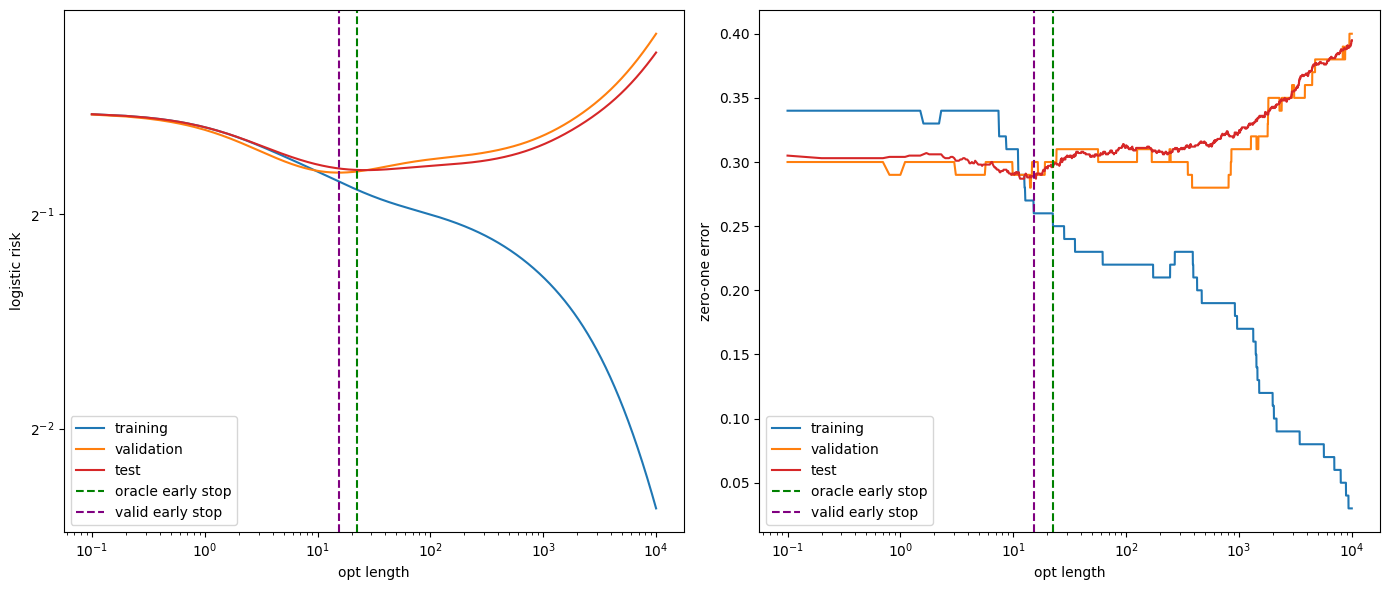

In [ ]:
n=100
m = 100

d=200

k=10

number_of_steps = int("1e5")

test_data_sample_size = 1000

# setting up w* -------
w_star = np.zeros(d)
w_star[:k]=1

# creating Sigma (basically a diagonal sigma) -----------
lambda_diag = np.arange(1, d+1, dtype=float) ** (-2)

eta = 0.1


# instantiating the class --------------------
logistic_class_instance = LogisticRegressionClass(n,d,random_seed=85)


X_data , y_data = logistic_class_instance.generate_data(
    d, n, w_star, use_lambda_diag= True, lambda_diag=lambda_diag
    )

X_valid , y_valid = logistic_class_instance.generate_data(
    d, m, w_star, use_lambda_diag= True, lambda_diag=lambda_diag
    )

X_test , y_test = logistic_class_instance.generate_data(
    d, test_data_sample_size, 
    w_star, use_lambda_diag= True, lambda_diag=lambda_diag
    )

result_trajectories = (
    logistic_class_instance.run_GD_for_t_steps
(
X_data, y_data, eta = eta, t_steps=number_of_steps, 
X_test= X_test, y_test=y_test, 
X_valid=X_valid, y_valid=y_valid,  
store_log_loss_traj_for_test=True,
store_zero_one_loss_traj_for_test=True,
store_log_loss_traj_for_validation=True,
store_zero_one_loss_traj_for_validation=True
)
)

L_hat_of_w_start_zero_to_k = logistic_class_instance.oracular_ell_hat_w_star_zero_to_k(X_data, y_data, w_star)

logistic_class_instance.plot(
        logistic_loss_training_trajectory = result_trajectories["log_loss_train"], 
        logistic_loss_test_trajectory=result_trajectories["log_loss_test"],
        logistic_loss_validation_trajectory=result_trajectories["log_loss_valid"],
        zero_one_loss_training_trajectory = result_trajectories["zero_one_train"], 
        zero_one_loss_test_trajectory=result_trajectories["zero_one_test"],
        zero_one_loss_validation_trajectory=result_trajectories["zero_one_valid"],
        eta = eta,
        show_oracular_early_stopping=True,
        L_hat_of_w_start_zero_to_k=L_hat_of_w_start_zero_to_k,
        show_validation_arg_min=True
        )


Experiment with 3 trajecory: (Here 3 is just a number)

Here we plot 3 (or n) trajectories in the desired two dimensional space, where one axis is w* and the other one is sum_i w_tilde_i for ith trajectory. We want to see what happens. 

In [ ]:
SELECTED

In [5]:
n=100
d=200

k=5 

w_star = np.zeros(d)
w_star[:k]=1
print (w_star)

[1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


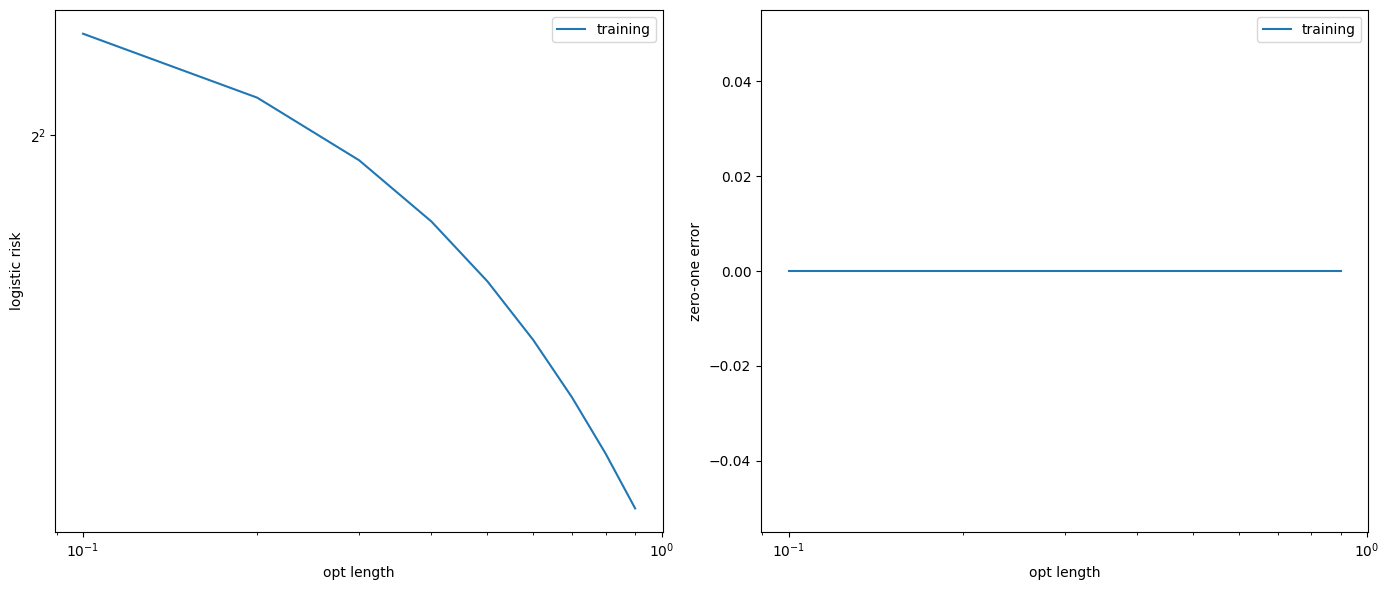

ValueError: operands could not be broadcast together with shapes (6,) (6,3) 

In [ ]:
logistic_class_isntance_2 = LogisticRegressionClass(random_seed=85)


In [13]:
print("some fun fact")

some fun fact
